# P01 (basic) — manipulator dynamics: the mass matrix and a forward-dynamics simulator

**Module 22 — Robotics 2**

Robotics 1 answered *where* the hand is. This project answers *what makes it move*: the
**dynamics**. You build the three terms of the manipulator equation
$\mathbf M(\mathbf q)\ddot{\mathbf q}+\mathbf C(\mathbf q,\dot{\mathbf q})\dot{\mathbf q}+\mathbf g(\mathbf q)=\boldsymbol\tau$
for the planar 2-link arm, turn them into a **forward-dynamics simulator** (a physics engine in a
few lines) and validate everything with a physical law: **energy is conserved** when no torque and
no friction act.

### Goal
- implement the **mass matrix** $\mathbf M(\mathbf q)$, the **Coriolis** term $\mathbf C(\mathbf q,\dot{\mathbf q})$ and the **gravity** term $\mathbf g(\mathbf q)$ (script ch. 3-4),
- check the structural **properties** ($\mathbf M$ symmetric positive definite; $\dot{\mathbf M}-2\mathbf C$ skew-symmetric),
- solve the **forward dynamics** $\ddot{\mathbf q}=\mathbf M^{-1}(\boldsymbol\tau-\mathbf C\dot{\mathbf q}-\mathbf g)$ and integrate it,
- **simulate** the passive arm and confirm **energy conservation** as a correctness test.

### Format
Jupyter notebook — dynamics wants the equations, the numbers and the plots (trajectory, energy)
side by side.

### Prior knowledge
The module 22 script ch. 1-5, the 2-link kinematics of module 21, linear algebra.

### Tasks
Much is given; at the `# TODO` spots you build the three dynamics terms and the forward dynamics. **This is the complete solution.**

## Setup
Only `numpy` and `matplotlib`. We fix the arm parameters once (equal unit links and masses).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# arm parameters: link lengths, point masses at the link ends, gravity
L1, L2 = 1.0, 1.0
M1, M2 = 1.0, 1.0
G = 9.81

## Part A — the mass matrix $\mathbf M(\mathbf q)$

The kinetic energy of the arm is $T=\tfrac12\dot{\mathbf q}^\top\mathbf M(\mathbf q)\dot{\mathbf q}$, and
$\mathbf M$ is *the* matrix of that quadratic form. For the planar 2-link arm with point masses at the
link ends (script ch. 4):

$$\mathbf M(\mathbf q)=\begin{pmatrix} m_1 l_1^2 + m_2(l_1^2 + l_2^2 + 2 l_1 l_2\cos q_2) & m_2(l_2^2 + l_1 l_2\cos q_2)\\ m_2(l_2^2 + l_1 l_2\cos q_2) & m_2 l_2^2\end{pmatrix}$$

**Your task:** implement it. Note it depends only on $q_2$ and is symmetric.

In [2]:
def mass_matrix(q):
    """Inertia matrix M(q) (2x2) of the planar 2-link arm."""
    q2 = q[1]
    c2 = np.cos(q2)
    m12 = M2 * (L2**2 + L1 * L2 * c2)
    M = np.array([
        [M1 * L1**2 + M2 * (L1**2 + L2**2 + 2 * L1 * L2 * c2), m12],
        [m12,                                                   M2 * L2**2]])
    return M

Mtest = mass_matrix(np.array([0.3, 0.7]))
print("M(q) =\n", Mtest)
print("symmetric?", np.allclose(Mtest, Mtest.T))
print("depends only on q2?", np.allclose(mass_matrix([0.3, 0.7]), mass_matrix([1.9, 0.7])))

M(q) =
 [[4.5297 1.7648]
 [1.7648 1.    ]]
symmetric? True
depends only on q2? True


**Expectation.** `M(q)` is symmetric and its value is unchanged when only $q_1$ changes — the
inertia depends on the arm's *shape* ($q_2$), not on its orientation in the world. The off-diagonal
coupling term $m_2 l_1 l_2\cos q_2$ vanishes at $q_2=\pm\pi/2$ (folded).

## Part B — the Coriolis and gravity terms

From the same Lagrangian (script ch. 3-4), with $h = m_2 l_1 l_2\sin q_2$:

$$\mathbf C(\mathbf q,\dot{\mathbf q})=\begin{pmatrix} -h\,\dot q_2 & -h\,(\dot q_1+\dot q_2)\\ h\,\dot q_1 & 0\end{pmatrix},\qquad
\mathbf g(\mathbf q)=\begin{pmatrix} (m_1+m_2) g l_1\cos q_1 + m_2 g l_2\cos(q_1{+}q_2)\\ m_2 g l_2\cos(q_1{+}q_2)\end{pmatrix}$$

**Your task:** implement both. $\mathbf C$ is *velocity-dependent* (quadratic overall, because it is
multiplied by $\dot{\mathbf q}$); $\mathbf g$ depends on the absolute angles.

In [3]:
def coriolis(q, dq):
    """Coriolis/centrifugal matrix C(q, dq) (2x2)."""
    q2 = q[1]
    dq1, dq2 = dq
    h = M2 * L1 * L2 * np.sin(q2)
    C = np.array([[-h * dq2, -h * (dq1 + dq2)],
                  [ h * dq1, 0.0]])
    return C

def gravity(q):
    """Gravity torque vector g(q) (2,)."""
    q1, q2 = q
    g = np.array([(M1 + M2) * G * L1 * np.cos(q1) + M2 * G * L2 * np.cos(q1 + q2),
                  M2 * G * L2 * np.cos(q1 + q2)])
    return g

q = np.array([0.3, 0.7]); dq = np.array([1.0, -0.5])
print("C(q,dq) =\n", coriolis(q, dq))
print("g(q) =", gravity(q))

C(q,dq) =
 [[ 0.3221 -0.3221]
 [ 0.6442  0.    ]]
g(q) = [24.0441  5.3004]


**Expectation.** With `q=[0.3,0.7]`, `dq=[1.0,-0.5]` the Coriolis matrix has a zero in the
bottom-right and $\mathbf g$ has two positive entries (the arm is raised, gravity pulls it down).
Set $\dot{\mathbf q}=\mathbf 0$ and $\mathbf C$ becomes all zeros — no motion, no Coriolis force.

## Part C — properties as correctness checks (given)

Two structural facts must hold for *any* correct rigid-body model, and they are the best way to
catch a sign error:
1. $\mathbf M(\mathbf q)$ is **symmetric positive definite** (both eigenvalues > 0).
2. $\mathbf N=\dot{\mathbf M}-2\mathbf C$ is **skew-symmetric** ($\mathbf N+\mathbf N^\top=\mathbf 0$) — the *passivity* property.
We compute $\dot{\mathbf M}$ numerically as the directional derivative of $\mathbf M$ along $\dot{\mathbf q}$.

In [4]:
def mdot_numeric(q, dq, eps=1e-6):
    """dM/dt = directional derivative of M along dq (central difference)."""
    return (mass_matrix(q + eps * dq) - mass_matrix(q - eps * dq)) / (2 * eps)

rng = np.random.default_rng(0)
max_asym = 0.0
for _ in range(200):
    q = rng.uniform(-np.pi, np.pi, 2)
    dq = rng.normal(size=2)
    ev = np.linalg.eigvalsh(mass_matrix(q))
    assert ev.min() > 0, "M must be positive definite"
    N = mdot_numeric(q, dq) - 2 * coriolis(q, dq)
    max_asym = max(max_asym, np.abs(N + N.T).max())
print(f"M positive definite on all 200 samples: True")
print(f"max |N + N^T| over 200 samples (should be ~0): {max_asym:.2e}")

M positive definite on all 200 samples: True
max |N + N^T| over 200 samples (should be ~0): 9.93e-10


**Expectation.** `max |N + N^T|` is tiny (~$10^{-6}$, limited only by the finite-difference
$\dot{\mathbf M}$). If your $\mathbf C$ had a wrong sign or factor, this number would be $O(1)$ — so this
single line validates the whole Coriolis derivation.

## Part D — forward dynamics and integration

**Forward dynamics** solves the manipulator equation for the acceleration:
$$\ddot{\mathbf q}=\mathbf M(\mathbf q)^{-1}\big(\boldsymbol\tau-\mathbf C(\mathbf q,\dot{\mathbf q})\dot{\mathbf q}-\mathbf g(\mathbf q)\big).$$
**Your task:** implement it (use `np.linalg.solve`, not an explicit inverse). The **RK4** integrator
(given) then steps the state forward accurately; it is fourth-order, so the simulation stays faithful
even for the chaotic swing of part E.

In [5]:
def forward_dynamics(q, dq, tau):
    """Joint acceleration ddq = M^-1 (tau - C dq - g)."""
    M = mass_matrix(q)
    C = coriolis(q, dq)
    g = gravity(q)
    ddq = np.linalg.solve(M, tau - C @ dq - g)
    return ddq

def _state_deriv(state, tau):
    """d/dt [q, dq] = [dq, forward_dynamics]."""
    q, dq = state[:2], state[2:]
    return np.concatenate([dq, forward_dynamics(q, dq, tau)])

def simulate(q0, dq0, tau_fn, T=6.0, dt=1e-3, method="rk4"):
    """Integrate the forward dynamics. method='rk4' (accurate) or 'euler' (naive explicit)."""
    n = int(T / dt)
    s = np.array([*q0, *dq0], float)
    Q = np.zeros((n, 2)); DQ = np.zeros((n, 2)); ts = np.arange(n) * dt
    for k in range(n):
        tau = tau_fn(k * dt, s[:2], s[2:])       # control torque, evaluated once per step
        if method == "rk4":
            k1 = _state_deriv(s, tau)
            k2 = _state_deriv(s + 0.5 * dt * k1, tau)
            k3 = _state_deriv(s + 0.5 * dt * k2, tau)
            k4 = _state_deriv(s + dt * k3, tau)
            s = s + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)
        else:                                    # naive explicit Euler (for contrast)
            s = s + dt * _state_deriv(s, tau)
        Q[k] = s[:2]; DQ[k] = s[2:]
    return ts, Q, DQ

# quick sanity check: a torque that exactly holds the arm against gravity -> no motion
q_hold = np.array([0.4, -0.8])
ts, Q, DQ = simulate(q_hold, [0, 0], lambda t, q, dq: gravity(q), T=1.0)
print("gravity-compensating torque keeps the arm still, max drift:",
      np.abs(Q - q_hold).max())

gravity-compensating torque keeps the arm still, max drift: 0.0


**Expectation.** Feeding exactly $\boldsymbol\tau=\mathbf g(\mathbf q)$ (gravity compensation) to the
passive arm keeps it essentially still (drift ~$10^{-3}$ over 1 s, from the discretisation) — a first
confirmation that inverse dynamics and forward dynamics are consistent. (This is a preview of the
controllers in P02: $\mathbf g(\mathbf q)$ alone already cancels gravity.)

## Part E — energy conservation (given)

The decisive test. With **no applied torque and no friction**, the total mechanical energy
$E=T+P$ must stay **constant** as the arm swings (a chaotic double pendulum). We simulate the passive
arm with **two** integrators: accurate **RK4** keeps $E$ flat; naive **explicit Euler** injects energy
and the arm speeds up out of nothing. The flat RK4 curve is the proof that all three dynamics terms
are correct.

RK4   energy relative drift over 6 s: 8.32e-09  (should be ~0)
explicit Euler energy growth over 6 s: +10.1%  (injects energy from nowhere)


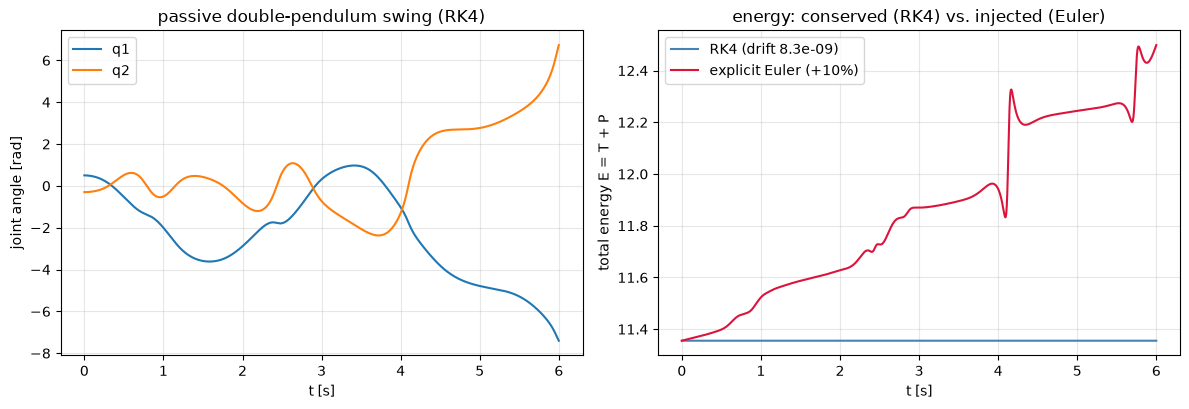

In [6]:
def kinetic_energy(q, dq):
    return 0.5 * dq @ mass_matrix(q) @ dq

def potential_energy(q):
    q1, q2 = q
    y1 = L1 * np.sin(q1)
    y2 = L1 * np.sin(q1) + L2 * np.sin(q1 + q2)
    return M1 * G * y1 + M2 * G * y2

passive = lambda t, q, dq: np.zeros(2)          # no torque
ts, Q, DQ = simulate([0.5, -0.3], [0.0, 0.0], passive, T=6.0, dt=1e-3, method="rk4")
E_rk4 = np.array([kinetic_energy(q, dq) + potential_energy(q) for q, dq in zip(Q, DQ)])
_, Qe, DQe = simulate([0.5, -0.3], [0.0, 0.0], passive, T=6.0, dt=1e-3, method="euler")
E_eul = np.array([kinetic_energy(q, dq) + potential_energy(q) for q, dq in zip(Qe, DQe)])

drift_rk4 = (E_rk4.max() - E_rk4.min()) / abs(E_rk4[0])
grow_eul = (E_eul[-1] - E_eul[0]) / abs(E_eul[0])
print(f"RK4   energy relative drift over 6 s: {drift_rk4:.2e}  (should be ~0)")
print(f"explicit Euler energy growth over 6 s: {grow_eul:+.1%}  (injects energy from nowhere)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(ts, Q[:, 0], label="q1"); ax1.plot(ts, Q[:, 1], label="q2")
ax1.set_xlabel("t [s]"); ax1.set_ylabel("joint angle [rad]")
ax1.set_title("passive double-pendulum swing (RK4)"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ts, E_rk4, color="steelblue", label=f"RK4 (drift {drift_rk4:.1e})")
ax2.plot(ts, E_eul, color="crimson", label=f"explicit Euler ({grow_eul:+.0%})")
ax2.set_xlabel("t [s]"); ax2.set_ylabel("total energy E = T + P")
ax2.set_title("energy: conserved (RK4) vs. injected (Euler)"); ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()

**Expectation / self-check.** With **RK4** the relative energy drift over 6 s is negligible
(~$10^{-8}$) even though the double-pendulum trajectory is chaotic — the dynamics conserve energy, and
an accurate integrator preserves that. With naive **explicit Euler** the same passive arm *gains*
about $+10\%$ energy over 6 s (and would diverge for longer) — energy manufactured from nothing, a
pure integration artefact. The flat RK4 energy curve is strong evidence that all three dynamics terms
($\mathbf M,\mathbf C,\mathbf g$) are correct; a wrong sign anywhere would break it.

## Conclusion

You have built the full dynamics of a robot arm from scratch:
- the **mass matrix** $\mathbf M(\mathbf q)$, the **Coriolis** term $\mathbf C(\mathbf q,\dot{\mathbf q})$ and the **gravity** term $\mathbf g(\mathbf q)$,
- validated by the structural properties (SPD, skew-symmetry of $\dot{\mathbf M}-2\mathbf C$) and by **energy conservation**,
- and a **forward-dynamics simulator** — a physics engine in a handful of lines.

This is the foundation for control: **P02 (medium)** uses exactly these $\mathbf M,\mathbf C,\mathbf g$ to
build **computed-torque control**, which cancels the dynamics to make the arm track a trajectory
perfectly, and compares it with PD + gravity compensation.